In [1]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("/home/sfr/release-volume-sampler/generated/messina_001/volumes/volumes.db")

# Query all data from the volumes table
df = pd.read_sql_query("SELECT * FROM volumes;", conn)

# Display the first few rows
print(df.head())

conn.close()

   id  released  condprob           area  mean_elevation  mean_slope  \
0   1      [35]  0.959328   83743.421369     -116.726662   15.432411   
1   2  [35, 36]  0.040672  166323.363153      -82.533333   13.809986   
2   3      [39]  0.578738  134517.162375     -135.346664   15.166469   
3   4  [39, 55]  0.065469  258433.405235     -108.013329   12.871271   
4   5  [39, 35]  0.306635  218260.583744     -126.036659   15.299440   

   seed_triangle  p_fos_seed         volume  thickness  \
0             35    0.007751  147716.570547   1.763919   
1             35    0.007751  375588.853523   2.258185   
2             39    0.007465  281419.335005   2.092070   
3             39    0.007465  683928.069418   2.646438   
4             39    0.007465  543528.960090   2.490275   

   tsunami_potential_ratio  p_shake  
0                 0.176427      0.0  
1                 0.605454      0.0  
2                 0.266438      0.0  
3                 0.678980      0.0  
4                 0.575834  

In [2]:
df.shape

(148698, 12)

In [4]:
import os
rundir = "/home/sfr/release-volume-sampler/generated/messina_001"
os.chdir("/home/sfr/release-volume-sampler/src")

In [5]:
from rvsampler.database_handler import VolumeDatabaseHandler

2025-04-24 07:54:12,166 - db_handler - INFO - Database connection initialized.
2025-04-24 07:54:15,795 - db_handler - INFO - Database connection closed.


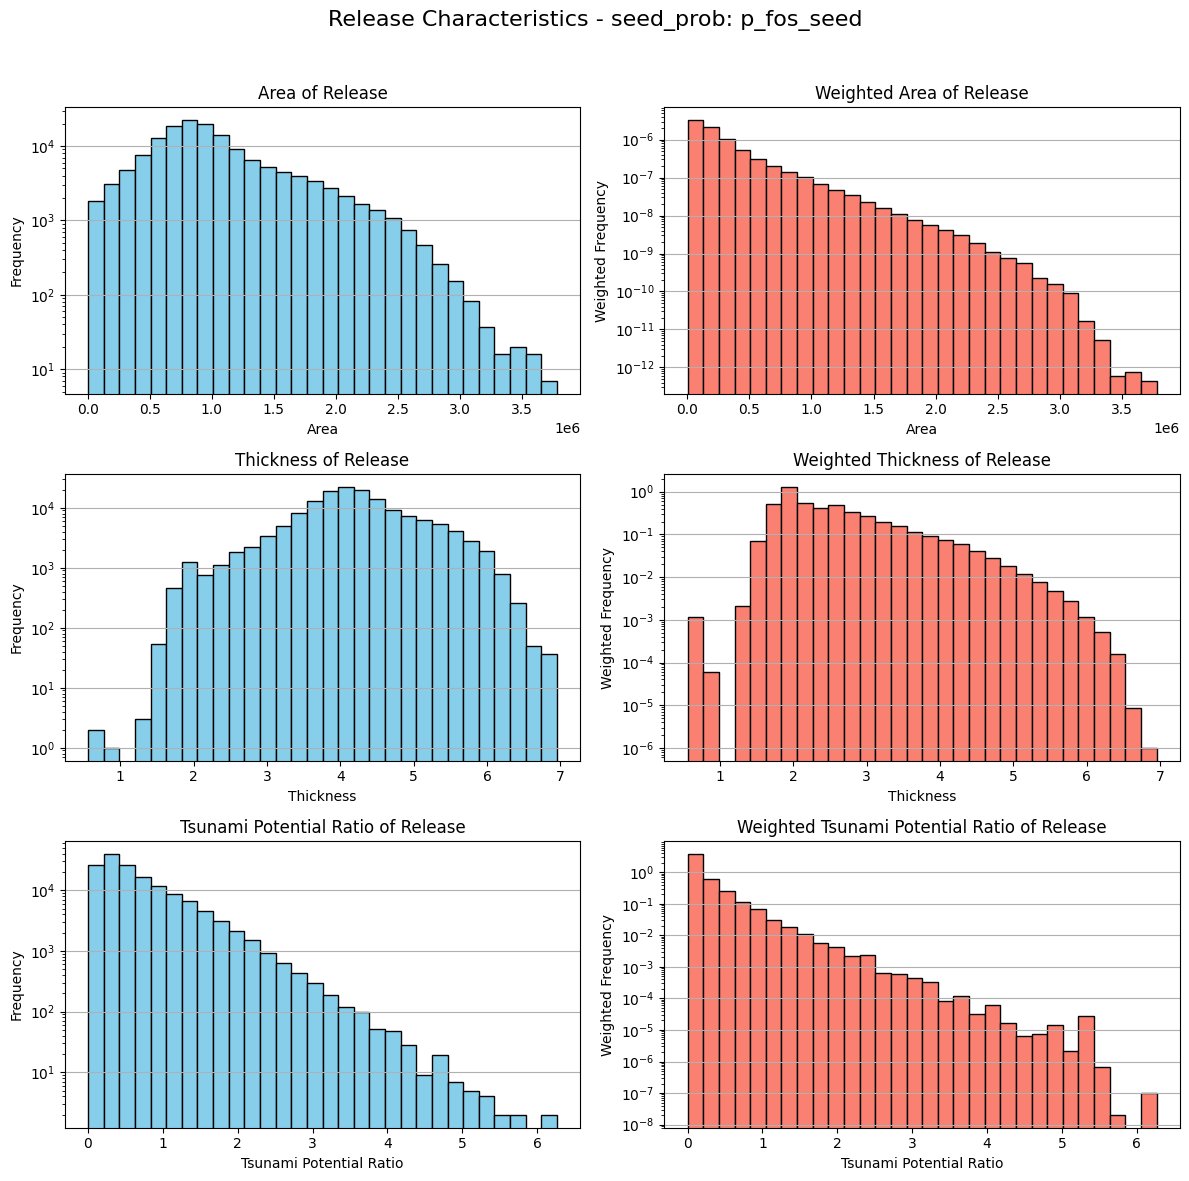

In [6]:
with VolumeDatabaseHandler(rundir) as volume_db:
    volume_db.plot_distribution()

In [7]:
with VolumeDatabaseHandler(rundir) as volume_db: 
    volume_db.plot_release_density_plots(seed_prob="p_shake")

2025-04-24 07:54:40,207 - db_handler - INFO - Database connection initialized.
2025-04-24 07:54:40,209 - db_handler - INFO -  Create spatial release density figure.
2025-04-24 07:54:41,445 - db_handler - INFO - Aggregated triangles: 0
2025-04-24 07:54:47,731 - db_handler - INFO - Aggregated triangles: 500
2025-04-24 07:54:54,132 - db_handler - INFO - Aggregated triangles: 1000
2025-04-24 07:55:00,319 - db_handler - INFO - Aggregated triangles: 1500
2025-04-24 07:55:06,777 - db_handler - INFO - Aggregated triangles: 2000
2025-04-24 07:55:13,074 - db_handler - INFO - Aggregated triangles: 2500
2025-04-24 07:55:19,078 - db_handler - INFO - Aggregated triangles: 3000
2025-04-24 07:55:24,656 - db_handler - INFO - Aggregated triangles: 3500
2025-04-24 07:55:30,158 - db_handler - INFO - Aggregated triangles: 4000
2025-04-24 07:55:35,467 - db_handler - INFO - Aggregated triangles: 4500
2025-04-24 07:55:40,977 - db_handler - INFO - Aggregated triangles: 5000
2025-04-24 07:55:46,255 - db_handler

In [8]:
from scipy.interpolate import interp1d
import numpy as np

displacement_threshold=5.
table_filename="exceedance_displacement.npz"
column_name = "p_shake"


volume_db = VolumeDatabaseHandler(rundir)
volume_db.__enter__()


2025-04-24 08:00:53,941 - db_handler - INFO - Database connection initialized.


In [9]:
COLUMN_NAMES = ['id', 'released', 'condprob',
           'area', 'mean_elevation', 'mean_slope', 
           'seed_triangle', 'p_fos_seed', 'volume', 
           'thickness', 'tsunami_potential_ratio']

In [10]:
# Load lookuptable
lookup_table_path = os.path.join(volume_db.triangulation_dir, table_filename)
volume_db.logger.info(f"Load exceedance probabilities: {lookup_table_path}.")
diplacement_exceedance = np.load(lookup_table_path)
thresholds, exceedance_probs = diplacement_exceedance["thresholds"], diplacement_exceedance["probs"]

interpolator = interp1d(x=thresholds, y=exceedance_probs, fill_value=(1.,0.), bounds_error=True)

#volume_db.df[name] = interpolator(displacement_threshold)[volume_db.df.seed_triangle.to_numpy()]
probabilities = interpolator(displacement_threshold)


2025-04-24 08:00:59,563 - db_handler - INFO - Load exceedance probabilities: /home/sfr/release-volume-sampler/generated/messina_001/triangulation/exceedance_displacement.npz.


In [11]:

volume_db.cursor.execute(f"SELECT id, seed_triangle FROM volumes")
rows = volume_db.cursor.fetchall()


In [12]:
updates = [(float(probabilities[row[1]]), row[0]) for row in rows]

In [13]:
updates

[(0.0, 1),
 (0.0, 2),
 (0.0, 3),
 (0.0, 4),
 (0.0, 5),
 (0.0, 6),
 (0.0, 7),
 (0.0, 8),
 (0.0, 9),
 (0.0, 10),
 (0.0, 11),
 (0.0, 12),
 (0.0, 13),
 (0.0, 14),
 (0.0, 15),
 (0.0, 16),
 (0.0, 17),
 (0.0, 18),
 (0.0, 19),
 (0.0, 20),
 (0.0, 21),
 (0.0, 22),
 (0.0, 23),
 (0.0, 24),
 (0.0, 25),
 (0.0, 26),
 (0.0, 27),
 (0.0, 28),
 (0.0, 29),
 (0.0, 30),
 (0.0, 31),
 (0.0, 32),
 (0.0, 33),
 (0.0, 34),
 (0.0, 35),
 (0.0, 36),
 (0.0, 37),
 (0.0, 38),
 (0.0, 39),
 (0.0, 40),
 (0.0, 41),
 (0.0, 42),
 (0.0, 43),
 (0.0, 44),
 (0.0, 45),
 (0.0, 46),
 (0.0, 47),
 (0.0, 48),
 (0.0, 49),
 (0.0, 50),
 (0.0, 51),
 (0.0, 52),
 (0.0, 53),
 (0.0, 54),
 (0.0, 55),
 (0.0, 56),
 (0.0, 57),
 (0.0, 58),
 (0.0, 59),
 (0.0, 60),
 (0.0, 61),
 (0.015691954642534256, 62),
 (0.015691954642534256, 63),
 (0.015691954642534256, 64),
 (0.015691954642534256, 65),
 (0.015691954642534256, 66),
 (0.015691954642534256, 67),
 (0.015691954642534256, 68),
 (0.015691954642534256, 69),
 (0.015691954642534256, 70),
 (0.015691954642

In [14]:

# Check if the 'probability' column exists
if column_name not in COLUMN_NAMES:
    volume_db.cursor.execute(f"ALTER TABLE volumes ADD COLUMN {column_name} REAL")
    volume_db.logger.info("Added {column_name} column to the table.")

# Loop through each row, calculate the probability, and update the row
volume_db.cursor.executemany(f"UPDATE volumes SET {column_name} = ? WHERE id = ?", updates)

volume_db.conn.commit()

OperationalError: duplicate column name: p_shake

In [15]:
[(row) for row in rows]

 ...]

In [ ]:
# Get column names
column_names = [description[0] for description in volume_db.cursor.description]


In [ ]:
column_names

In [ ]:

# Check if the 'probability' column exists
if column_name not in column_names:
    volume_db.cursor.execute(f"ALTER TABLE volumes ADD COLUMN {column_name} REAL")
    volume_db.logger.info("Added 'probability' column to the table.")

# Loop through each row, calculate the probability, and update the row
volume_db.cursor.executemany(f"UPDATE volumes SET {column_name} = ? WHERE id = ?", (probabilities[row_dict["seed_triangle"]], row_dict['id']))

volume_db.conn.commit()